## phase 1 : Data understanding

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Read the dataset using pandas

In [2]:
df= pd.read_csv(r"student_performance_dataset_6000_real_names.csv")


In [3]:
# performing basic operations to understand what the dataset is about

In [4]:
df.head()

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
0,Kimberly Flores,NaN,74,69,74,NaN,48530.0,Yes,6.3,Placed
1,George Williams,79.0,46,60,65,Music,92980.0,No,4.3,Placed
2,Paul Nguyen,96.9,70,94,88,Sports,81558.0,Yes,6.7,Placed
3,Laura Moore,90.2,52,57,80,Sports,71822.0,Yes,4.4,Not Placed
4,Angela Harris,NaN,67,80,76,Sports,10745.0,Yes,4.6,Placed


In [5]:
df.shape

(6100, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6100 entries, 0 to 6099
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student Name       6100 non-null   str    
 1   Attendance %       5798 non-null   float64
 2   Internal Marks     6100 non-null   int64  
 3   Final Marks        6100 non-null   str    
 4   Assignment Scores  6100 non-null   int64  
 5   Extra Activities   5124 non-null   str    
 6   Family Income      5850 non-null   float64
 7   Internet Access    6100 non-null   str    
 8   Study Hours        6100 non-null   float64
 9   Placement Status   6100 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 476.7 KB


In [7]:
df.describe()

,Attendance %,Internal Marks,Assignment Scores,Family Income,Study Hours
count,5798.000000,6100.000000,6100.000000,5850.000000,6100.000000
mean,79.882442,63.924262,73.174918,65598.278974,5.507213
std,11.390175,63.485575,18.610559,27690.948326,1.948208
min,37.900000,-15.000000,5.000000,8000.000000,1.000000
25%,72.200000,49.000000,60.000000,46347.000000,4.100000
50%,80.100000,60.000000,74.000000,64715.500000,5.500000
75%,88.100000,71.000000,88.000000,84305.000000,6.900000
max,100.000000,999.000000,100.000000,180471.000000,10.000000


In [8]:
# check whether there is null values and duplicate values in dataset 

In [9]:
df.isnull().sum() # gives total missing value 

Student Name           0
Attendance %         302
Internal Marks         0
Final Marks            0
Assignment Scores      0
Extra Activities     976
Family Income        250
Internet Access        0
Study Hours            0
Placement Status       0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(100)

In [11]:
duplicates = df[df.duplicated()]
duplicates.head()

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
6000,Emily Jones,80.2,83,85,77,Debate,94377.0,Yes,7.0,Placed
6001,Donald Jackson,98.6,64,82,77,Volunteer,46877.0,No,6.1,Placed
6002,Joshua Wright,69.5,66,C,71,Sports,95784.0,No,5.3,Not Placed
6003,Joseph Lopez,73.6,67,61,77,Sports,88888.0,Yes,6.7,Placed
6004,Mary Garcia,81.3,57,C,40,Sports,76604.0,Yes,2.1,Not Placed


# phase 2: Data cleaning

In [12]:
# Removing the duplicate value from the dataset

In [13]:
df= df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
# filling in the missing values

In [16]:
# for attendence we use median 

In [17]:
df["Attendance %"].median()

np.float64(80.0)

In [18]:
# for extra activites we use mode

In [19]:
df["Extra Activities"].mode()

0    Sports
Name: Extra Activities, dtype: str

In [20]:
# for family income we use median as values can be sekwed

In [21]:
df["Family Income"].median()

np.float64(64702.0)

In [22]:
# now we fill in the values

In [23]:
df["Attendance %"]=df["Attendance %"].fillna(df["Attendance %"].median())
df["Extra Activities"]=df["Extra Activities"].fillna(df["Extra Activities"].mode()[0])
df["Family Income"]=df["Family Income"].fillna(df["Family Income"].median())

In [24]:
df.isnull().sum()

Student Name         0
Attendance %         0
Internal Marks       0
Final Marks          0
Assignment Scores    0
Extra Activities     0
Family Income        0
Internet Access      0
Study Hours          0
Placement Status     0
dtype: int64

In [25]:
# check the data type in the dataset if they are in correct form or not 

In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student Name       6000 non-null   str    
 1   Attendance %       6000 non-null   float64
 2   Internal Marks     6000 non-null   int64  
 3   Final Marks        6000 non-null   str    
 4   Assignment Scores  6000 non-null   int64  
 5   Extra Activities   6000 non-null   str    
 6   Family Income      6000 non-null   float64
 7   Internet Access    6000 non-null   str    
 8   Study Hours        6000 non-null   float64
 9   Placement Status   6000 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 468.9 KB


In [27]:
# here final marks is in object type it should be int or float so

In [28]:
df["Final Marks"].value_counts()

Final Marks
69    169
66    162
72    155
68    151
67    143
     ... 
25      3
18      1
20      1
13      1
15      1
Name: count, Length: 88, dtype: int64

In [29]:
df["Final Marks"].unique()

<StringArray>
[    '69',     '60',     '94',     '57',     '80',     '90',     '77',
     '58',     '87',     '76',     '92',     '66',     '88',     '47',
     '55',     '50',     '54',     '46',     '79',     '74',     '63',
     '67',     '62',     '70',     '72',     '64',     '49', 'Absent',
     '73',     '71',     '59',     '84',     '78',     '43',      'B',
     '65',     '68',     '81',     '44',     '97',     '61',     '83',
     '56',     '91',     '38',     '89',     '82',     '52',      'C',
     '53',    '100',     '37',      'A',     '75',     '45',     '22',
     '41',     '48',     '85',     '39',     '51',     '86',     '99',
     '96',     '98',     '29',     '93',     '33',     '36',     '42',
     '95',     '31',     '23',     '40',     '32',     '24',     '34',
     '30',     '26',     '21',     '18',     '28',     '35',     '27',
     '25',     '20',     '13',     '15']
Length: 88, dtype: str

In [30]:
# here a b c and absent are also present which we need to fix : 

In [31]:
# at first we need to locate the places 

In [32]:
df["Final Marks"].value_counts().loc[["A","B","C","Absent"]]

Final Marks
A         101
B          78
C          73
Absent     98
Name: count, dtype: int64

In [33]:
# ## since the final marks datatype should be numeric to change it to integer we need to replace A=90,B=80,C=70 and absent=0

In [34]:
df["Final Marks"]=df["Final Marks"].replace({
    "A":90,
    "B":80,
    "C":70,
    "Absent":0
})

In [35]:
# checking 

In [36]:
df["Final Marks"].unique()

array(['69', '60', '94', '57', '80', '90', '77', '58', '87', '76', '92',
       '66', '88', '47', '55', '50', '54', '46', '79', '74', '63', '67',
       '62', '70', '72', '64', '49', 0, '73', '71', '59', '84', '78',
       '43', 80, '65', '68', '81', '44', '97', '61', '83', '56', '91',
       '38', '89', '82', '52', 70, '53', '100', '37', 90, '75', '45',
       '22', '41', '48', '85', '39', '51', '86', '99', '96', '98', '29',
       '93', '33', '36', '42', '95', '31', '23', '40', '32', '24', '34',
       '30', '26', '21', '18', '28', '35', '27', '25', '20', '13', '15'],
      dtype=object)

In [37]:
# HERE dtype is still object so:

In [38]:
df["Final Marks"]= df["Final Marks"].astype(int)


### Outlier Analysis

#### Boxplots were created for Internal Marks, Final Marks, and Assignment Scores to detect potential outliers.

#### A few low-score outliers were identified. These values were retained because they represent genuine student performance rather than data entry errors. Keeping them is important for identifying at-risk students and performing realistic educational analysis.

In [39]:
# for internal marks

In [40]:
df.head()

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
0,Kimberly Flores,80.0,74,69,74,Sports,48530.0,Yes,6.3,Placed
1,George Williams,79.0,46,60,65,Music,92980.0,No,4.3,Placed
2,Paul Nguyen,96.9,70,94,88,Sports,81558.0,Yes,6.7,Placed
3,Laura Moore,90.2,52,57,80,Sports,71822.0,Yes,4.4,Not Placed
4,Angela Harris,80.0,67,80,76,Sports,10745.0,Yes,4.6,Placed


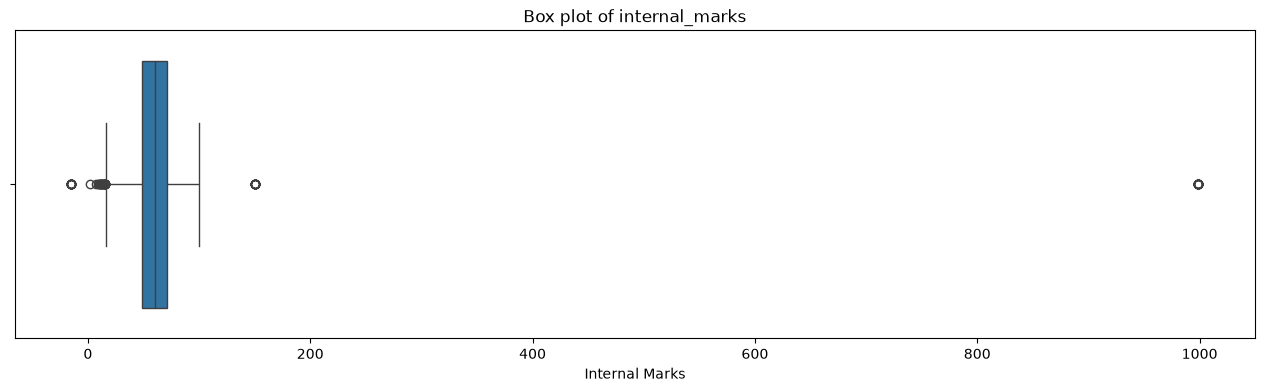

In [41]:
plt.figure(figsize=(16,4))
sns.boxplot(x=df["Internal Marks"])
plt.title("Box plot of internal_marks")
plt.show()

In [42]:
# for final Marks

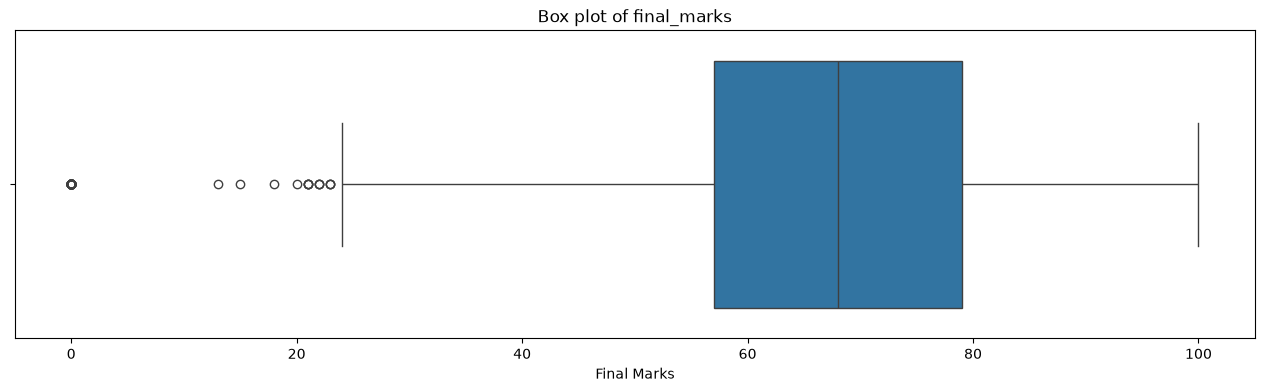

In [43]:
plt.figure(figsize=(16,4))
sns.boxplot(x=df["Final Marks"])
plt.title("Box plot of final_marks")
plt.show()

In [44]:
# for assignment scores

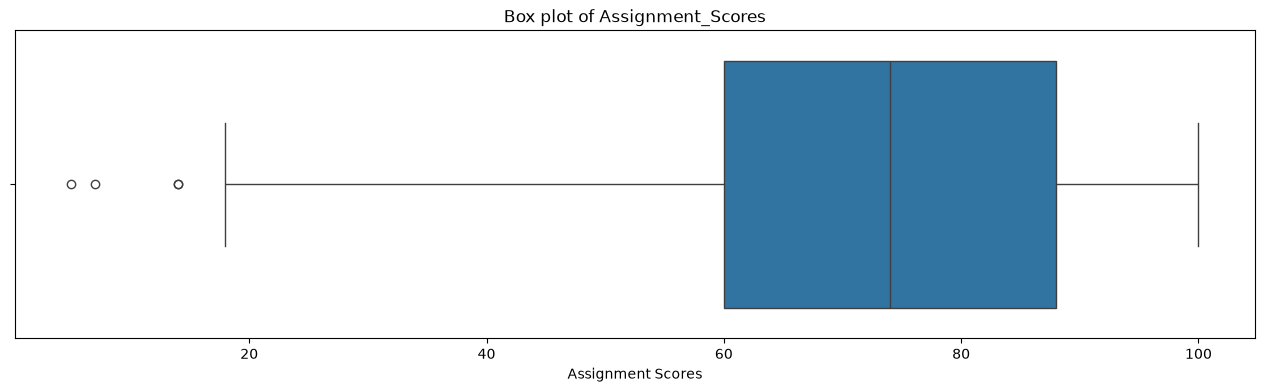

In [45]:
plt.figure(figsize=(16,4))
sns.boxplot(x=df["Assignment Scores"])
plt.title("Box plot of Assignment_Scores")
plt.show()

# phase 3: Exploratary Data anlaysis

In [46]:
# statistical summary

In [47]:
df.describe()

,Attendance %,Internal Marks,Final Marks,Assignment Scores,Family Income,Study Hours
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,79.884417,64.000333,66.756667,73.192000,65537.405833,5.506667
std,11.124276,63.972682,17.117660,18.555337,27113.884023,1.942863
min,37.900000,-15.000000,0.000000,5.000000,8000.000000,1.000000
25%,72.600000,49.000000,57.000000,60.000000,47091.000000,4.100000
50%,80.000000,60.000000,68.000000,74.000000,64702.000000,5.500000
75%,87.600000,71.000000,79.000000,88.000000,83310.500000,6.900000
max,100.000000,999.000000,100.000000,100.000000,180471.000000,10.000000


In [48]:
# here in internal marks minimum values is in negative and maximum value is over 100 which we need to fix

In [49]:
df[df['Internal Marks']<0]

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
679,Jennifer Garcia,95.8,-15,66,69,Debate,32046.0,No,5.2,Placed
920,Amanda Clark,80.1,-15,50,63,NCC,63314.0,No,4.7,Not Placed
1157,Patricia Taylor,66.8,-15,84,100,Volunteer,34306.0,Yes,7.0,Placed
1171,Jessica Clark,68.5,-15,81,88,NCC,29198.0,Yes,5.3,Placed
1925,Susan Wilson,92.4,-15,51,64,Sports,37646.0,Yes,3.4,Not Placed
2095,Sandra Sanchez,86.4,-15,41,47,Music,14691.0,No,2.6,Not Placed
2727,Sandra Jackson,77.3,-15,57,55,Music,33909.0,Yes,3.3,Not Placed
2880,Rebecca Thompson,87.7,-15,57,43,Sports,41623.0,No,3.7,Not Placed
3644,Emma Lewis,76.5,-15,63,55,Music,44425.0,No,3.7,Placed
3651,Stephanie Johnson,67.6,-15,41,45,Debate,55693.0,Yes,2.1,Not Placed


In [50]:
df[df['Internal Marks']>100]

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
168,Nancy Robinson,52.1,150,52,72,Music,45382.0,Yes,3.7,Not Placed
175,Nicholas Allen,81.3,150,68,75,Volunteer,85294.0,No,6.7,Placed
295,Angela Hill,79.1,999,71,73,Sports,23833.0,No,5.9,Placed
363,Brian Ramirez,74.1,999,75,39,Volunteer,152512.0,Yes,2.9,Placed
721,Linda Perez,81.4,150,76,65,Debate,78596.0,No,5.3,Placed
998,Karen Brown,82.8,999,65,73,Sports,52835.0,No,5.3,Placed
1174,Steven Thompson,71.0,999,67,78,Music,92643.0,No,6.5,Placed
1351,Sandra Robinson,81.6,150,58,40,NCC,27085.0,Yes,2.4,Not Placed
2090,Michelle Walker,80.6,999,80,74,Volunteer,28452.0,Yes,7.4,Placed
2269,Daniel Robinson,88.3,999,89,89,Volunteer,71314.0,Yes,6.3,Placed


In [51]:
#  since there are too many outlier in internalmarks we need tto replace them by taking median of valid marks

In [52]:
valid_marks=df[(df['Internal Marks']<100) & (df['Internal Marks']>0)]['Internal Marks'].median()

In [53]:
valid_marks

np.float64(60.0)

In [54]:
# now we need to replace with the valid marks

In [55]:
df["Internal Marks"]=df["Internal Marks"].replace({
    -15 : valid_marks,
    999 : valid_marks,
    150 : valid_marks
})

In [56]:
# checking

In [57]:
df[df['Internal Marks']>100]

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status


In [58]:
# drawing histogram to visualize the all numeric columns

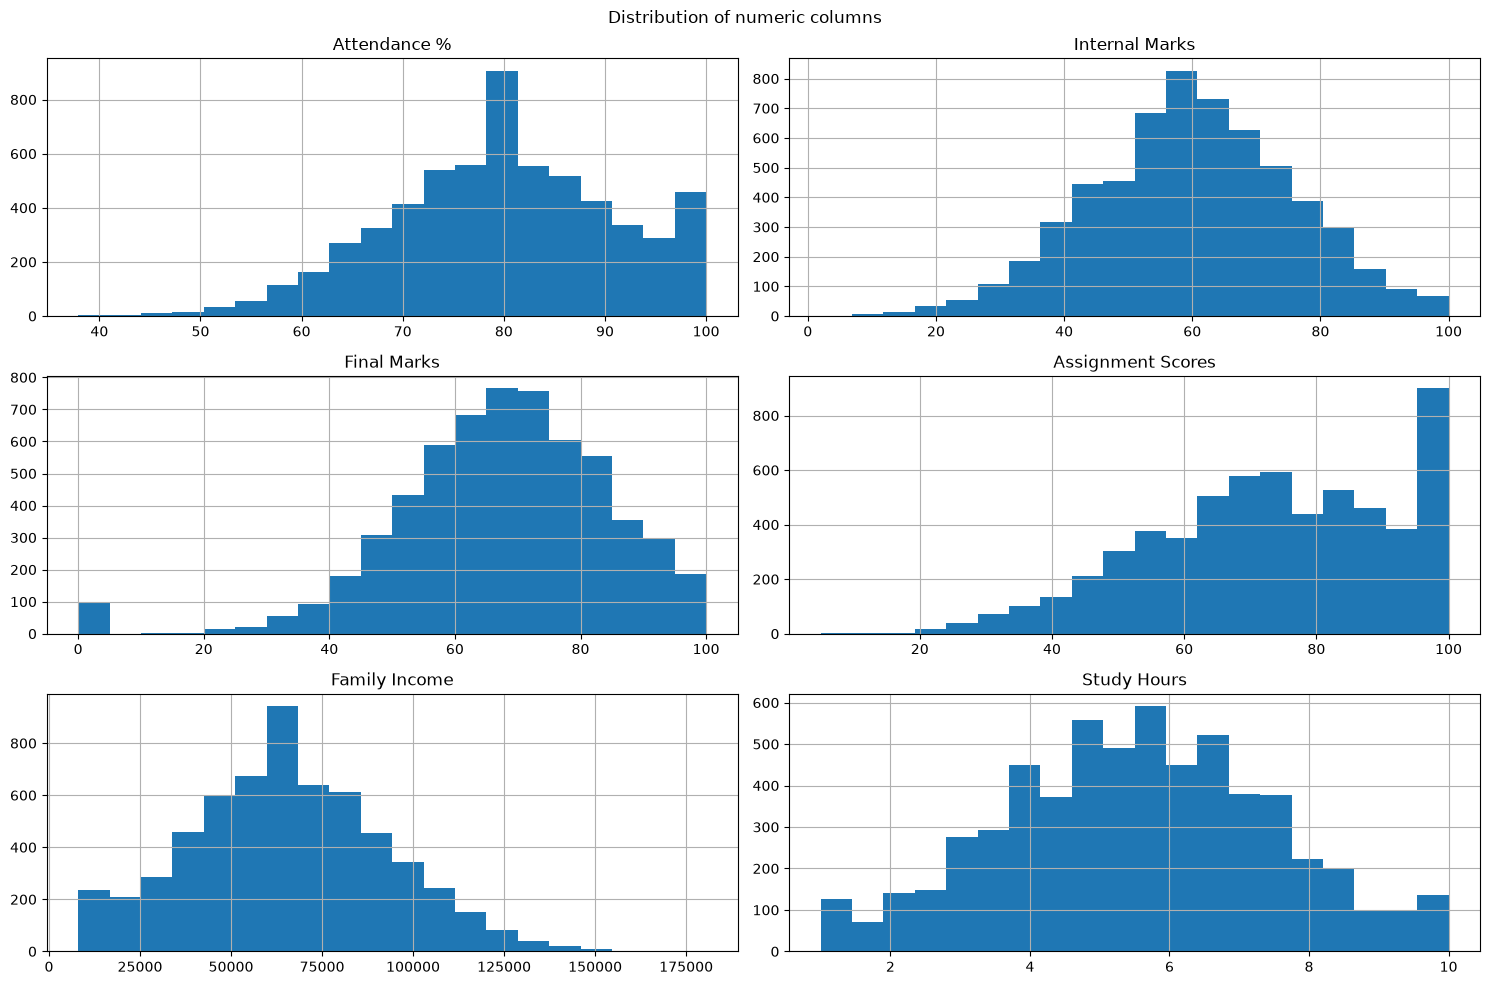

In [59]:
df.hist(figsize=(15,10),bins=20)
plt.suptitle("Distribution of numeric columns")
plt.tight_layout()
plt.show()

In [60]:
# now we have to answer 

In [61]:
# attendance vs final_marks

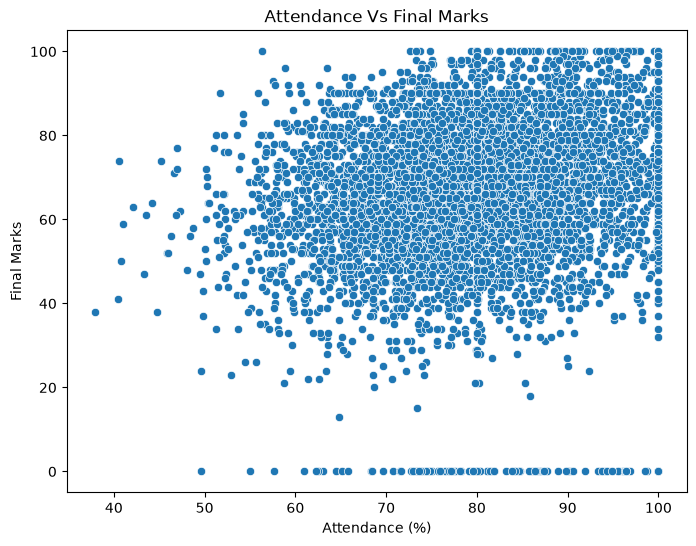

In [62]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Attendance %"],
    y=df["Final Marks"],
    alpha=1
)

plt.title("Attendance Vs Final Marks")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Marks")
plt.show()

In [63]:
# study hours vs final marks

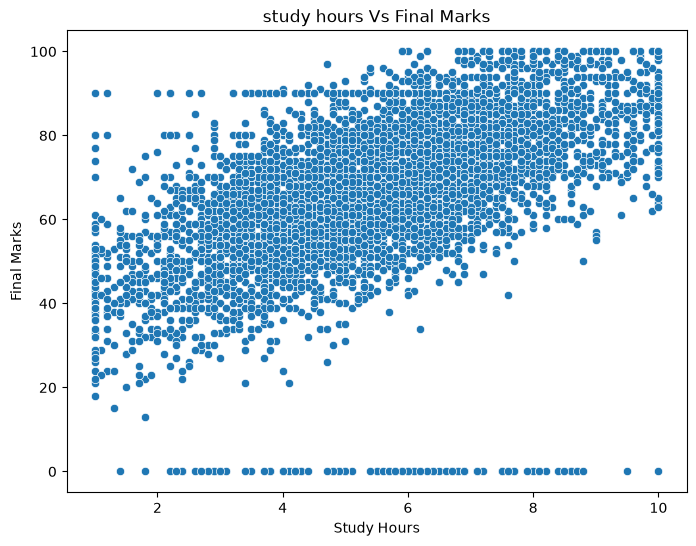

In [65]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["Study Hours"],
    y=df["Final Marks"],
    alpha=1
)

plt.title("study hours Vs Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.show()

In [64]:
# observation:  The scatter plot shows a clear positive relationship between study hours and final marks. 
#Students who spend more time studying generally achieve higher scores.
#However, the variation in marks among students with similar study hours suggests that additional factors also influence academic performance.

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status
0,Kimberly Flores,80.0,74,69,74,Sports,48530.0,Yes,6.3,Placed
1,George Williams,79.0,46,60,65,Music,92980.0,No,4.3,Placed
2,Paul Nguyen,96.9,70,94,88,Sports,81558.0,Yes,6.7,Placed
3,Laura Moore,90.2,52,57,80,Sports,71822.0,Yes,4.4,Not Placed
4,Angela Harris,80.0,67,80,76,Sports,10745.0,Yes,4.6,Placed


In [66]:
# internet access vs final marks

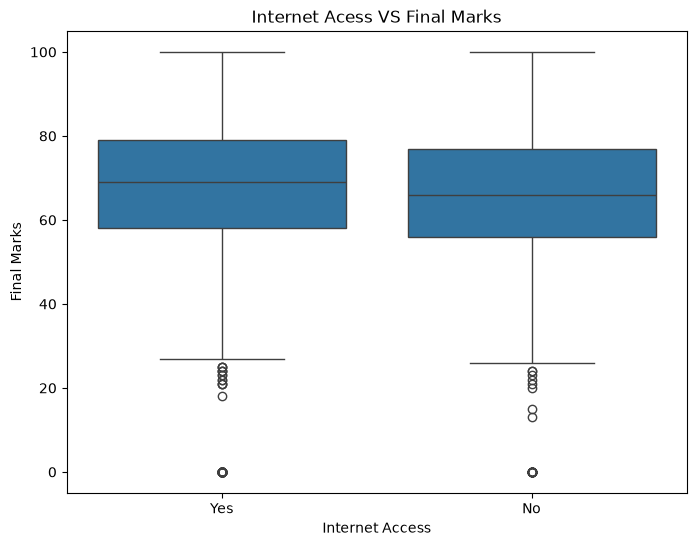

In [67]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df["Internet Access"],
            y=df["Final Marks"])
plt.title("Internet Acess VS Final Marks")
plt.xlabel("Internet Access")
plt.ylabel("Final Marks")
plt.show()

In [68]:
#Does internet access improve scores?
#Students with internet access have a slightly higher median final mark, but the distributions are very similar. 
#Therefore, internet access may help academic performance, but it is not the strongest factor affecting final marks.

In [69]:
# family income vs student performance

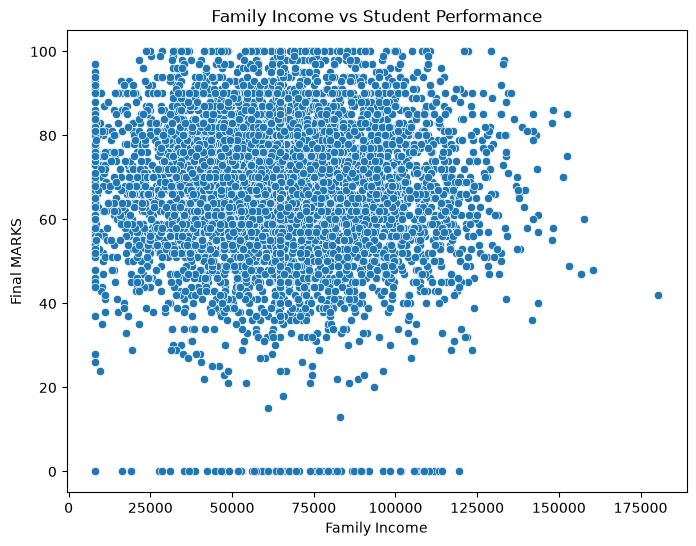

In [70]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df["Family Income"],
                 y=df["Final Marks"]
                )
plt.title("Family Income vs Student Performance")
plt.xlabel("Family Income")
plt.ylabel("Final MARKS")
plt.show()

In [72]:
#Does Family Income Affect Student Performance?
#=Observation: The scatter plot shows no strong correlation between family income and final marks. 
#Students from both lower- and higher-income families achieved a wide range of scores, 
#suggesting that family income alone is not a major determinant of academic performance.

In [73]:
# drawing heatmap to show how strongly the numerical columns are related to each other

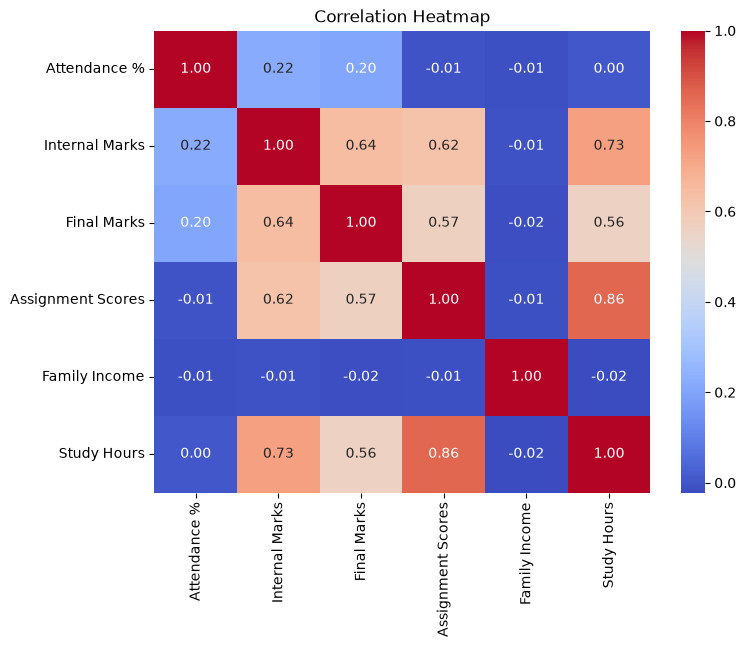

In [74]:
plt.figure(figsize=(8,6))

correlation = df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [75]:
#Observation: The correlation heatmap indicates that Internal Marks (0.64), Assignment Scores (0.57), 
#and Study Hours (0.56) have moderate to strong positive relationships with Final Marks. 
#Attendance shows only a weak positive correlation (0.20), while Family Income has almost no correlation (-0.02). 
#This suggests that academic performance is more closely associated with students' study habits 
#and continuous assessments than with family income.

# phase 4 : Feature Engineering

In [77]:
# create a new column called average score which will help for the further analysis

In [78]:
df["Average Score"]=(
    df["Final Marks"]+
    df["Internal Marks"]+
    df["Assignment Scores"])/3

In [79]:
df["Average Score"].head()

0    72.333333
1    57.000000
2    84.000000
3    63.000000
4    74.333333
Name: Average Score, dtype: float64

In [80]:
# now we move to risk category where we have to make function 

In [81]:
def risk_category(score):
    if score<40:
        return "At risk"
    elif score <60:
        return "Need Improvement"
    else:
        return "safe"

In [82]:
risk_category(43)

'Need Improvement'

In [83]:
# SO APPLYING RISK category for all the values of average score

In [84]:
df["Risk Category"]=df["Average Score"].apply(risk_category)

In [85]:
df.head()

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status,Average Score,Risk Category
0,Kimberly Flores,80.0,74,69,74,Sports,48530.0,Yes,6.3,Placed,72.333333,safe
1,George Williams,79.0,46,60,65,Music,92980.0,No,4.3,Placed,57.000000,Need Improvement
2,Paul Nguyen,96.9,70,94,88,Sports,81558.0,Yes,6.7,Placed,84.000000,safe
3,Laura Moore,90.2,52,57,80,Sports,71822.0,Yes,4.4,Not Placed,63.000000,safe
4,Angela Harris,80.0,67,80,76,Sports,10745.0,Yes,4.6,Placed,74.333333,safe


In [86]:
# performance label

In [87]:
def performance_level(score):
    if score >= 85:
        return "Excellent"
    elif score >=70:
        return "Good"
    elif score >=50:
        return "Average"
    else:
        return "Poor"

In [89]:
df["Performance_Level"]=df["Average Score"].apply(performance_level)

In [90]:
df.head()

,Student Name,Attendance %,Internal Marks,Final Marks,Assignment Scores,Extra Activities,Family Income,Internet Access,Study Hours,Placement Status,Average Score,Risk Category,Performance_Level
0,Kimberly Flores,80.0,74,69,74,Sports,48530.0,Yes,6.3,Placed,72.333333,safe,Good
1,George Williams,79.0,46,60,65,Music,92980.0,No,4.3,Placed,57.000000,Need Improvement,Average
2,Paul Nguyen,96.9,70,94,88,Sports,81558.0,Yes,6.7,Placed,84.000000,safe,Good
3,Laura Moore,90.2,52,57,80,Sports,71822.0,Yes,4.4,Not Placed,63.000000,safe,Average
4,Angela Harris,80.0,67,80,76,Sports,10745.0,Yes,4.6,Placed,74.333333,safe,Good


In [91]:
# export the dataset

In [92]:
df.to_csv("Student_Performance_System.csv",index=False)

In [93]:
# to verify

In [94]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Student_analysis.ipynb',
 'student_performance_dataset_6000_real_names.csv',
 'Student_Performance_System.csv']